In [1]:
#import necessary libraries with ML model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import time
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Covid_Severity_Classification.csv')
df['CLASIFFICATION_FINAL'].value_counts()

3.0    1030460
1.0       9055
0.0       3110
2.0       2028
Name: CLASIFFICATION_FINAL, dtype: int64

In [3]:

# Split the data into features and target variable
X = df.drop('DIED', axis=1)
y = df['DIED']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Train the model
rf_classifier.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = rf_classifier.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9429316264406693


In [4]:
X = df.drop('DIED', axis=1)  # Features without the 'DIED' column
y = df['DIED']  # Target variable 'DIED'

# Create and train the random forest model
rf_classifier.fit(X, y)

# Predict probabilities for the whole dataset
df['PROBABILITY'] = rf_classifier.predict_proba(X)[:, 1]

# Print the updated DataFrame with the 'PROBABILITY' column
df.to_csv('MortalityRisk_Predictions.csv', index = False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044653 entries, 0 to 1044652
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   SEX                   1044653 non-null  int64  
 1   AGE                   1044653 non-null  int64  
 2   PNEUMONIA             1044653 non-null  float64
 3   PREGNANT              1044653 non-null  int64  
 4   DIABETES              1044653 non-null  float64
 5   ASTHMA                1044653 non-null  float64
 6   INMSUPR               1044653 non-null  float64
 7   HIPERTENSION          1044653 non-null  float64
 8   CARDIOVASCULAR        1044653 non-null  float64
 9   COPD                  1044653 non-null  float64
 10  RENAL_CHRONIC         1044653 non-null  float64
 11  OBESITY               1044653 non-null  float64
 12  TOBACCO               1044653 non-null  float64
 13  INTUBED               1044653 non-null  float64
 14  ICU                   1044653 non-

In [6]:
#show important features that were used for prediction mortality

importance_scores = rf_classifier.feature_importances_
importance_scores

array([0.01153517, 0.27491998, 0.22870713, 0.00047473, 0.02747657,
       0.0046947 , 0.00659431, 0.02169801, 0.0078704 , 0.00755623,
       0.01041649, 0.01090898, 0.00877918, 0.31918529, 0.02067702,
       0.01364543, 0.02486037])

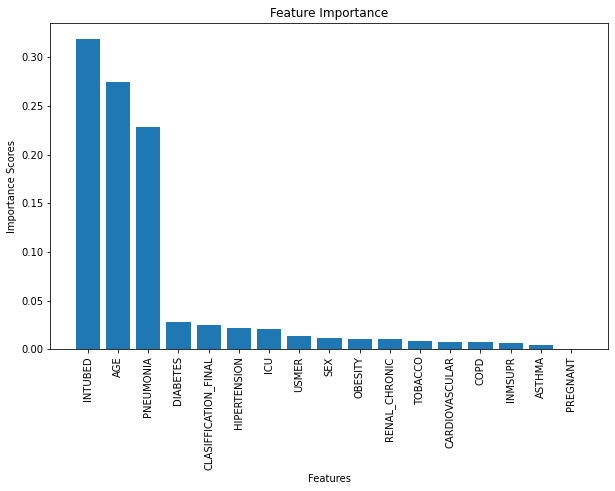

In [7]:
df1 = df.drop('DIED', axis=1)
column_names = list(df1.columns)

feature_importance = dict(zip(column_names, importance_scores))
sorted_feature_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# Extract the sorted column names and importance scores
sorted_columns, sorted_scores = zip(*sorted_feature_importance)

# Plot the feature importance in a bar graph
plt.figure(figsize=(10, 6))
plt.bar(sorted_columns, sorted_scores)
plt.xlabel('Features')
plt.ylabel('Importance Scores')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

In [8]:
women_df = pd.read_csv('Women_Severity_Classification.csv')

In [9]:
X = women_df.drop('DIED', axis=1)  # Features
y = women_df['DIED']  # Target

# Create a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the classifier to the data
clf.fit(X, y)

# Get feature importances
feature_importances = clf.feature_importances_

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print(importance_df)


                 Feature  Importance
1                    AGE    0.302563
13               INTUBED    0.299584
2              PNEUMONIA    0.217189
4               DIABETES    0.028390
7           HIPERTENSION    0.025514
16  CLASIFFICATION_FINAL    0.025146
14                   ICU    0.017872
15                 USMER    0.015905
11               OBESITY    0.013106
10         RENAL_CHRONIC    0.012371
9                   COPD    0.009164
8         CARDIOVASCULAR    0.009121
6                INMSUPR    0.008275
12               TOBACCO    0.008107
5                 ASTHMA    0.006578
3               PREGNANT    0.001116
0                    SEX    0.000000


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521310 entries, 0 to 521309
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   SEX                   521310 non-null  int64  
 1   AGE                   521310 non-null  int64  
 2   PNEUMONIA             521310 non-null  float64
 3   PREGNANT              521310 non-null  int64  
 4   DIABETES              521310 non-null  float64
 5   ASTHMA                521310 non-null  float64
 6   INMSUPR               521310 non-null  float64
 7   HIPERTENSION          521310 non-null  float64
 8   CARDIOVASCULAR        521310 non-null  float64
 9   COPD                  521310 non-null  float64
 10  RENAL_CHRONIC         521310 non-null  float64
 11  OBESITY               521310 non-null  float64
 12  TOBACCO               521310 non-null  float64
 13  INTUBED               521310 non-null  float64
 14  ICU                   521310 non-null  float64
 15  

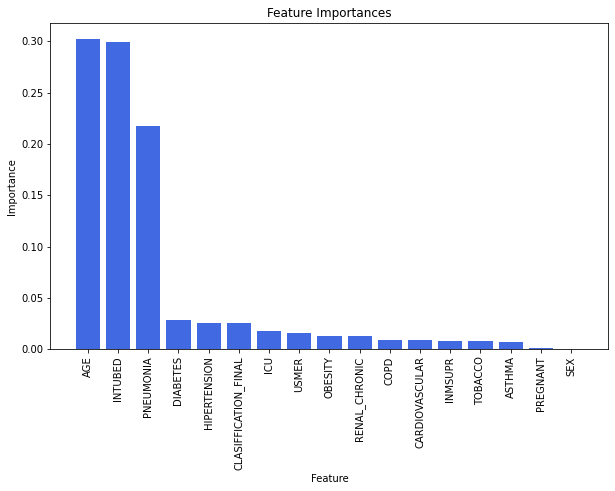

In [11]:

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='royalblue')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility if needed
plt.show()
